In [1]:
from core.em_project import EMProject
from geometry.primitives import RectangularWaveguide, CircularWaveguide

# 1. Start project
project_name = 'multi_rwg'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

# 2. Create assembly
assembly = proj.create_assembly(main_axis='Z')

# 3. Add components
wg1 = RectangularWaveguide(a=0.1, L=0.1)
# wg2 = RectangularWaveguide(a=0.1, L=0.1)

assembly.add("rwg1", wg1)
assembly.add("rwg1", wg1, after="rwg1")

# 4. Build and save
assembly.build()
assembly.generate_mesh(maxh=0.02)
# assembly.show('mesh')
proj.geo.show('mesh')

Project 'multi_rwg' exists. Loading automatically...
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_rwg
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [2]:
geo = proj.geo
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 100,
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    # 'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Compound structure
INFO:: Domains (2): ['rwg1', 'rwg1_1']
INFO:: Total Ports (3): ['port1', 'port2', 'port3']
INFO:: External Ports (2): ['port1', 'port3']
INFO:: Internal Ports (1): ['port2']
INFO:: 
Domain-Port Mapping:
  rwg1: ['port1 (external, input)', 'port2 (internal)']
  rwg1_1: ['port2 (internal)', 'port3 (external, output)']

Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port2: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port3: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  Precomputing boundary mass matrices (once per port)...
	    Done for 3 port(s)
here is the order of the p

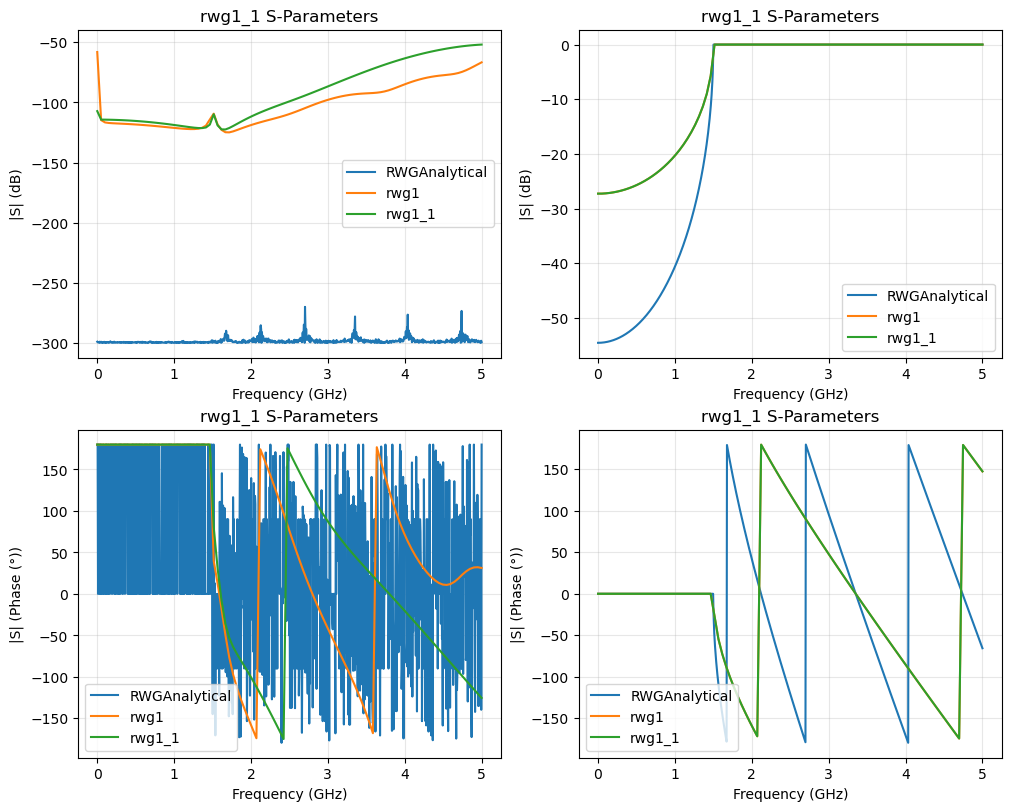

In [3]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt

# Get analytic solution for comparison
from analytical.rectangular_waveguide import RWGAnalytical

analytical = RWGAnalytical(a=0.1, L=0.2, freq_range=(fom_config['fmin'], fom_config['fmax']))

# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1])
    proj.fds.foms.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.foms.plot_s(wh, plot_type='phase', ax=axs[idx+3])

In [4]:
# Reduce model order
roms = proj.fds.foms.reduce()
concat = proj.fds.foms.roms.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    # 'rerun': True
}
rom_result = concat.solve(config=roms_config) # solve reduced order model on more frequency samples


ImportError: cannot import name 'ModelOrderReduction' from 'rom.reduction' (C:\Users\Soske\Documents\git_projects\cavsim3d\rom\reduction.py)

In [ ]:

from analytical.rectangular_waveguide import RWGAnalytical

analytical = RWGAnalytical(a=0.1, L=0.2, freq_range=(fom_config['fmin'], fom_config['fmax']))

# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\circular_wg')
# plot comparison
which = [['1(1)1(1)'], ['1(1)2(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(10, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    analytical.plot_s(wh, ax=axs[idx+1], lw=3)
    concat.plot_s(wh, ax=axs[idx+1])
    # plot phase
    analytical.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=5)
    concat.plot_s(wh, plot_type='phase', ax=axs[idx+3])


In [ ]:
proj.fds.fom.plot_

In [ ]:
# from core.em_project import EMProject
# from geometry.assembly import Assembly
# from geometry.primitives import RectangularWaveguide, CircularWaveguide
# # =============================================================================
# # Basic Sequential Assembly
# # =============================================================================
#
# # Create waveguide sections
# wg1 = RectangularWaveguide(a=0.1, L=0.3, maxh=0.02)
# wg2 = RectangularWaveguide(a=0.1, L=0.5, maxh=0.02)
# wg3 = RectangularWaveguide(a=0.1, L=0.2, maxh=0.02)
#
# # Check tags - wg1 and wg3 have same geometry params (different L though)
# print(f"wg1 tag: {wg1.tag}")
# print(f"wg2 tag: {wg2.tag}")
#
# # Build assembly
# assembly = Assembly(main_axis='Z')
# assembly.add("input", wg1)
# assembly.add("middle", wg2, after="input")
# assembly.add("output", wg3, after="middle")
#
# # Preview before building
# assembly.inspect()
#
# # Build and mesh
# assembly.build()
# assembly.generate_mesh(maxh=0.02)
# assembly.show("mesh")
#
# # Check assembly info
# assembly.print_info()
#
#
# # # =============================================================================
# # # Example 2: Mosaic Layout (T-Junction)
# # # =============================================================================
#
# # # Load T-junction from STEP file
# # t_junction = STEPImporter("t_junction.step", unit='mm', auto_build=True)
#
# # # Create waveguide branches
# # wg_horizontal = RectangularWaveguide(a=0.1, L=0.4, maxh=0.02)
# # wg_vertical = RectangularWaveguide(a=0.1, L=0.3, maxh=0.02)
#
# # # Define layout using mosaic
# # layout = '''
# #     .     top      .
# #   left   center  right
# # '''
#
# # assembly = Assembly.from_mosaic(
# #     layout,
# #     components={
# #         'center': t_junction,
# #         'top': wg_vertical,
# #         'left': wg_horizontal,
# #         'right': wg_horizontal  # Same object used twice!
# #     },
# #     grid_plane='XY',
# #     spacing=0.0
# # )
#
# # # Note: 'left' and 'right' share the same geometry object
# # # The solver can compute once and reuse the solution
# # unique = assembly.get_unique_components()
# # print(f"Unique geometries: {len(unique)}")  # Will be 3, not 4
#
# # assembly.build()
# # assembly.show()
#
#
